In [6]:
# Import Libraries and load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

# Suppress warnings in the notebook
import warnings
warnings.filterwarnings("ignore")

# Load the data
df = pd.read_csv("us_retail_sales.csv")

# Inspect columns
df.head()

,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC
0,1992,146925,147223,146805,148032,149010,149800,150761.0,151067.0,152588.0,153521.0,153583.0,155614.0
1,1993,157555,156266,154752,158979,160605,160127,162816.0,162506.0,163258.0,164685.0,166594.0,168161.0
2,1994,167518,169649,172766,173106,172329,174241,174781.0,177295.0,178787.0,180561.0,180703.0,181524.0
3,1995,182413,179488,181013,181686,183536,186081,185431.0,186806.0,187366.0,186565.0,189055.0,190774.0
4,1996,189135,192266,194029,194744,196205,196136,196187.0,196218.0,198859.0,200509.0,200174.0,201284.0


The dataset is in a wide format. It has one row per year and one column per month.  
To build a time series model, I need a single column of dates and a single column of sales values.  
So I am reshaping the data from wide to long format.

In [7]:
# Convert from wide to long format
df_long = df.melt(id_vars="YEAR", var_name="Month", value_name="Sales")

# Create a proper datetime column object to use in the modeling
df_long['Date'] = pd.to_datetime(df_long['YEAR'].astype(str) + "-" + df_long['Month'], format="%Y-%b")

# Dropping blank values created by the datetime reshaping
df_long = df_long.dropna(subset=["Sales"])

# Sort by date
df_long = df_long.sort_values("Date")

# Setting the index so that the modeling sees the date as a time series
df_long = df_long.set_index("Date")

# Keep only the sales column since the date is now the index column and the only other usable value is the Sales
timeSeries = df_long['Sales']

timeSeries.head(400)

Date
1992-01-01    146925.0
1992-02-01    147223.0
1992-03-01    146805.0
1992-04-01    148032.0
1992-05-01    149010.0
                ...   
2021-02-01    504458.0
2021-03-01    559871.0
2021-04-01    562269.0
2021-05-01    548987.0
2021-06-01    550782.0
Name: Sales, Length: 354, dtype: float64

## 1. Plotting the Time Series to visualize the full trend.


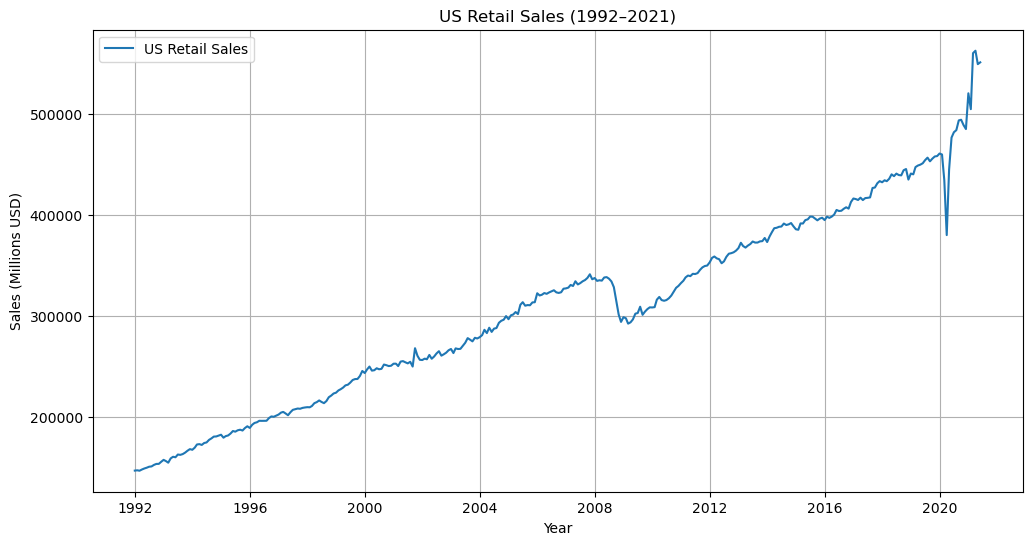

In [8]:
plt.figure(figsize=(12,6))
plt.plot(timeSeries, label="US Retail Sales")
plt.title("US Retail Sales (1992–2021)")
plt.xlabel("Year")
plt.ylabel("Sales (Millions USD)")
plt.grid(True)
plt.legend()
plt.show()

### Observations

- There is an upward trend during in the timeframe.
- In early 2020 there is a sharp drop and then a quick return most likely due to COVID.
- Overall the volatility increases over time.

## 2. Train/Test Split

Splitting the Training and Test data based on assignment requirements. The training dataset is from Janurary 1992 through June 2020 and the test dataset from July 2020 through June 2021.


In [15]:
# setting test dataset starting date
test_start = "2020-07-01"

train = timeSeries.loc[timeSeries.index < test_start]
test = timeSeries.loc[timeSeries.index >= test_start]

len(train), len(test)

(342, 12)

## 3. Building Predictive Models (ARIMA and SARIMA)

The ARIMA(1,1,1) model provides a simple baseline forecast, but the retail sales data clearly shows seasonality. To improve the model, I will also fit a SARIMA model with a seasonal component of 12 months. This allows the model to capture recurring annual patterns that ARIMA cannot.

In [16]:
# Fitting the ARIMA model
model = ARIMA(train, order=(1,1,1))
fitted = model.fit()

fitted.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Sales   No. Observations:                  342
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -3446.039
Date:                Sun, 15 Feb 2026   AIC                           6898.078
Time:                        19:51:30   BIC                           6909.574
Sample:                    01-01-1992   HQIC                          6902.658
                         - 06-01-2020                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5740      0.288      1.991      0.046       0.009       1.139
ma.L1         -0.6137      0.287     -2.142      0.032      -1.175      -0.052
sigma2      3.464e+07    1.6e-07   2.17e+14      0.000    3.46e+07    3.46e+07
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):             55412.08
Prob(Q):                              0.96   Prob(JB):                         0.00
Heteroskedasticity (H):              21.03   Skew:                             0.81
Prob(H) (two-sided):                  0.00   Kurtosis:                        65.43
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 5.03e+28. Standard errors may be unstable.
"""

In [12]:
# fitting the SARIMA model for seasonality
from statsmodels.tsa.statespace.sarimax import SARIMAX

# SARIMA model with seasonal order (P,D,Q,12)
sarima_model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12))
sarima_fitted = sarima_model.fit()

sarima_fitted.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                              Sales   No. Observations:                  342
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -3357.035
Date:                            Sun, 15 Feb 2026   AIC                           6724.070
Time:                                    19:50:45   BIC                           6743.051
Sample:                                01-01-1992   HQIC                          6731.642
                                     - 06-01-2020                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6827      0.176      3.876      0.000       0.338       1.028
ma.L1         -0.7563      0.173     -4.366      0.000      -1.096      -0.417
ar.S.L12       0.5074      0.066      7.711      0.000       0.378       0.636
ma.S.L12      -0.8559      0.101     -8.433      0.000      -1.055      -0.657
sigma2      4.564e+07    2.7e-08   1.69e+15      0.000    4.56e+07    4.56e+07
===================================================================================
Ljung-Box (L1) (Q):                   0.17   Jarque-Bera (JB):             22090.12
Prob(Q):                              0.68   Prob(JB):                         0.00
Heteroskedasticity (H):               5.99   Skew:                             0.09
Prob(H) (two-sided):                  0.00   Kurtosis:                        43.14
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 5.47e+29. Standard errors may be unstable.
"""

## 4. Forecasting the Last 12 Months (ARIMA vs SARIMA)

Here I generate 12 month forecasts using both models.  
ARIMA provides a baseline, while SARIMA incorporates seasonality and should better follow the real pattern.


In [19]:
# forecast modeling vs actual using both ARIMA and SARIMA
forecast = fitted.forecast(steps=len(test))
forecast.index = test.index  # makes the plot line up correctly

sarima_forecast = sarima_fitted.forecast(steps=len(test))

sarima_results = pd.DataFrame({
    "Actual": test,
    "ARIMA_Forecast": forecast,
    "SARIMA_Forecast": sarima_forecast
})

sarima_results

,Actual,ARIMA_Forecast,SARIMA_Forecast
2020-07-01,481627.0,474543.788328,476208.059929
2020-08-01,483716.0,473510.986197,476357.051072
2020-09-01,493327.0,472918.126413,473183.539157
2020-10-01,493991.0,472577.806896,474525.631732
2020-11-01,488652.0,472382.453160,475753.037896
2020-12-01,484782.0,472270.314183,475507.844057
2021-01-01,520162.0,472205.943006,477457.857779
2021-02-01,504458.0,472168.991995,477108.640190
2021-03-01,559871.0,472147.780993,461136.927278
2021-04-01,562269.0,472135.605234,426061.947738


### Visual Comparison of ARIMA vs SARIMA Forecasts

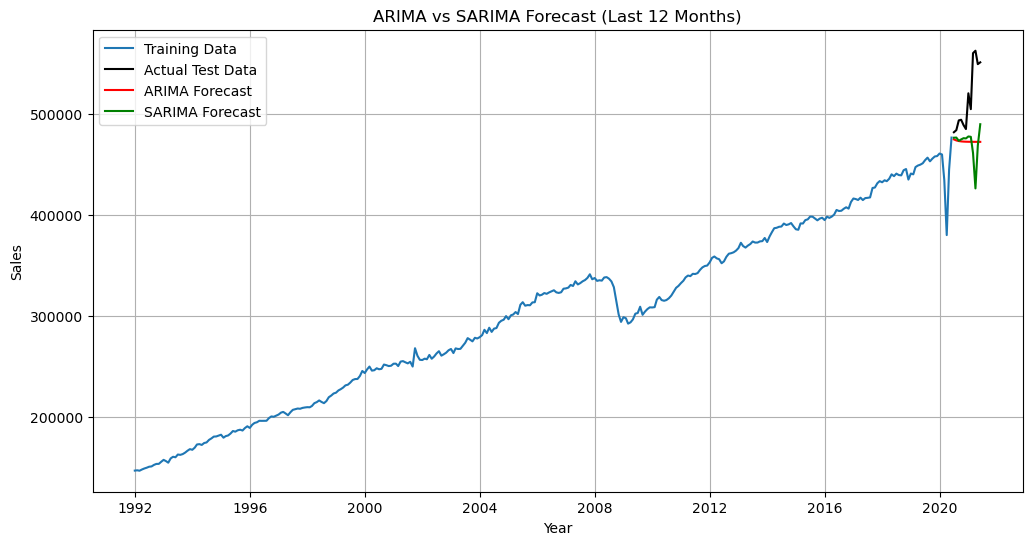

In [20]:
plt.figure(figsize=(12,6))
plt.plot(train, label="Training Data")
plt.plot(test, label="Actual Test Data", color='black')
plt.plot(forecast, label="ARIMA Forecast", color='red')
plt.plot(sarima_forecast, label="SARIMA Forecast", color='green')
plt.title("ARIMA vs SARIMA Forecast (Last 12 Months)")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

### Observations

When I looked at the ARIMA(1,1,1) forecast, it pretty much was a flat line for the 12 month test period. After seeing how the model works, this makes sense. The last part of the training data is really messy because of the COVID drop and then the big increase. ARIMA doesn't work well that kind of volatility. Instead of trying to follow the drastic changes, it settles into a steady level and stays there. That’s why the forecast doesn’t match the big increase in the actual 2021 values.

I expected SARIMA to do better since it includes seasonality, but the seasonal pattern in this dataset gets messed up in the last couple of years. COVID breaks the usual cycle, so SARIMA doesn’t have a normal seasonal pattern to learn from. Because of those issues, SARIMA also produces a mostly flat forecast. It’s slightly different from ARIMA, but it still can’t capture the big changes in the test data. Both models struggle for the same reason.

## 5. RMSE Comparison

To evaluate model accuracy, I compute RMSE for both ARIMA and SARIMA.  
Lower RMSE indicates a better fit.

In [22]:
# Calculating RMSE
arima_rmse = np.sqrt(mean_squared_error(test, forecast))
sarima_rmse = np.sqrt(mean_squared_error(test, sarima_forecast))

arima_rmse, sarima_rmse

(np.float64(52206.76375888313), np.float64(59307.28212442381))

### Observations

When I compared the RMSE values, ARIMA ended up doing better than SARIMA. ARIMA had an RMSE of about 52,206, while SARIMA was higher at around 59,307. I would expect SARIMA to perform better on monthly data because it includes seasonality, but that didn’t happen here. A big reason for this is like I mentioned earlier, the seasonal pattern in the last couple of years of the dataset isn’t stable. COVID caused a huge drop and then a quick rebound. This threw off the usual seasonal cycle. Since SARIMA depends on that seasonal pattern, it didn’t have much to work with and couldn’t take advantage of its seasonal features. ARIMA doesn’t depend on seasonality, so the broken seasonal pattern didn’t affect it as much. Even though its forecast was pretty flat, it still ended up closer to the real values.
